[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qubvel-org/segmentation_models.pytorch/blob/main/examples/oxford_pet_segmentation_and_classification.ipynb)

🇭 🇪 🇱 🇱 🇴 👋

This example shows how to fine-tune a model with a segmentation head and an **auxiliary classification head** using `segmentation-models-pytorch`. We will use [The Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/): each pixel of an input image is classified either as pet 🐶🐱 or as background (segmentation) and, at the same time, the whole image is classified as a cat 🐱 or a dog 🐶 (classification).

Such multi-task models are useful when an image-level prediction is needed along with the mask: e.g. "is the target class present on the image at all?", scene type, image quality or, like in this example, a species. The classification head is built on top of the encoder, so it is cheap in terms of compute, and both tasks share (and jointly train) the same encoder features.

What we are going to cover in this example:

 - 📜 Adding a classification target to a segmentation `Dataset`.
 - 🔀 Creating a model with an auxiliary classification head (`aux_params`).
 - ➕ Combining segmentation (`Dice`) and classification (`BCE`) losses.
 - 📈 Computing `IoU` for the segmentation head and `accuracy` / `F1` for the classification head inside a `LightningModule`.
 - 🐶 Results visualization.

> It is expected you are familiar with Python, PyTorch and have some experience with training neural networks before! It is also recommended to look through the [binary segmentation example](https://github.com/qubvel-org/segmentation_models.pytorch/blob/main/examples/binary_segmentation_intro.ipynb) first: this example follows its structure and only explains the parts related to the classification head.

In [1]:
%%capture
!pip install -U git+https://github.com/qubvel-org/segmentation_models.pytorch
!pip install lightning

In [2]:
import os

import numpy as np
import torch
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from torch.optim import lr_scheduler
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, default_collate

## Dataset

We will reuse the predefined `SimpleOxfordPetDataset` (see the [binary segmentation example](https://github.com/qubvel-org/segmentation_models.pytorch/blob/main/examples/binary_segmentation_intro.ipynb) for the dataset preparation checklist) and extend it with a classification target. The dataset returns a `sample` dict with keys `image` and `mask`, and we will add a `label` key: `0` for a cat and `1` for a dog.

Where does the label come from? The Oxford-IIIT Pet split files (`annotations/trainval.txt` and `annotations/test.txt`) already store a species id for every image (`1` = cat, `2` = dog); the base dataset just does not use it. We read this column and return it with each sample.

💡 For datasets where the target class may be absent from some images (e.g. `CamVid`), a good classification target is the **existence** of the class on the image: `1` if at least one pixel of the class is present in the mask, `0` otherwise. Every Oxford Pet image contains a pet, so here we use the species instead.

In [3]:
from segmentation_models_pytorch.datasets import SimpleOxfordPetDataset

In [4]:
# download data
root = "."
SimpleOxfordPetDataset.download(root)

In [5]:
class OxfordPetWithSpeciesDataset(SimpleOxfordPetDataset):
    """SimpleOxfordPetDataset with an image-level `label`: 0 - cat, 1 - dog."""

    def __init__(self, root, mode="train"):
        super().__init__(root, mode)

        # each line of a split file looks like "yorkshire_terrier_187 37 2 25"
        # (<image name> <class id> <species: 1 - cat, 2 - dog> <breed id>)
        split_filename = "test.txt" if mode == "test" else "trainval.txt"
        split_filepath = os.path.join(root, "annotations", split_filename)
        with open(split_filepath) as f:
            lines = f.read().strip("\n").split("\n")

        self.species = {
            line.split(" ")[0]: int(line.split(" ")[2]) - 1 for line in lines
        }

    def __getitem__(self, idx):
        sample = super().__getitem__(idx)

        # shape (1,) to match the classification head output (batch_size, 1)
        label = self.species[self.filenames[idx]]
        sample["label"] = np.array([label], dtype=np.float32)

        return sample

In [6]:
# init train, val, test sets
train_dataset = OxfordPetWithSpeciesDataset(root, "train")
valid_dataset = OxfordPetWithSpeciesDataset(root, "valid")
test_dataset = OxfordPetWithSpeciesDataset(root, "test")

# it is a good practice to check datasets don`t intersects with each other
assert set(test_dataset.filenames).isdisjoint(set(train_dataset.filenames))
assert set(test_dataset.filenames).isdisjoint(set(valid_dataset.filenames))
assert set(train_dataset.filenames).isdisjoint(set(valid_dataset.filenames))

print(f"Train size: {len(train_dataset)}")
print(f"Valid size: {len(valid_dataset)}")
print(f"Test size: {len(test_dataset)}")

# `num_workers=0` keeps the example portable: dataset classes defined in a
# notebook can not be unpickled by dataloader workers on Windows/macOS
# (`spawn` start method), on Linux/Colab it can be increased to speed up
# data loading
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
valid_dataloader = DataLoader(
    valid_dataset, batch_size=64, shuffle=False, num_workers=0
)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

Train size: 3312
Valid size: 368
Test size: 3669


In [7]:
species_names = ["cat", "dog"]


def get_species_indices(dataset, species_id, count):
    """Return `count` indices of dataset samples of the given species.

    The splits are ordered by breed, with all cat breeds first, so both
    classes have to be looked up explicitly to be seen together.
    """
    indices = [
        i
        for i, filename in enumerate(dataset.filenames)
        if dataset.species[filename] == species_id
    ]
    return indices[:count]

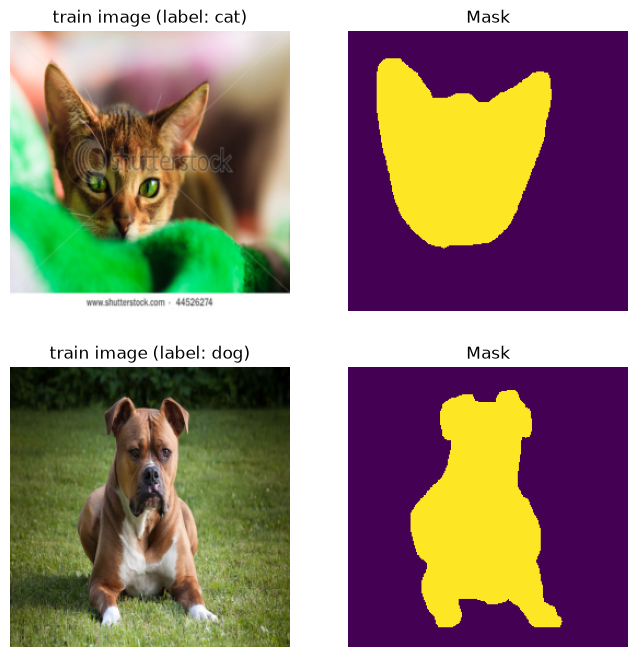

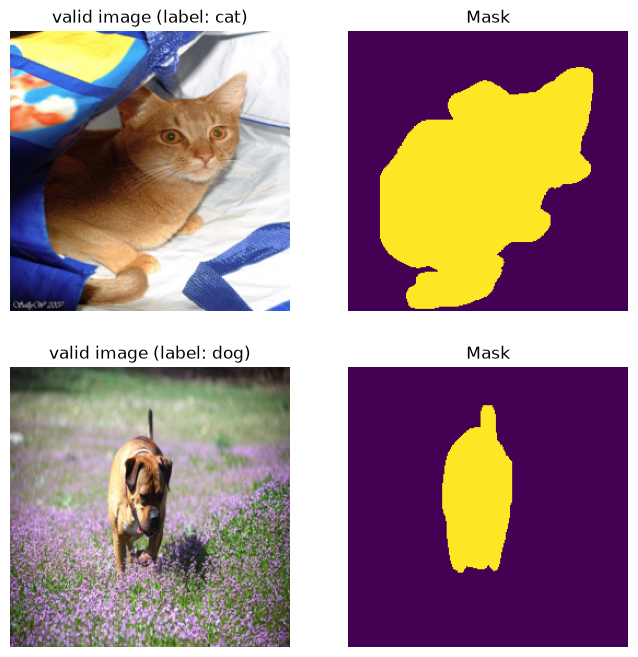

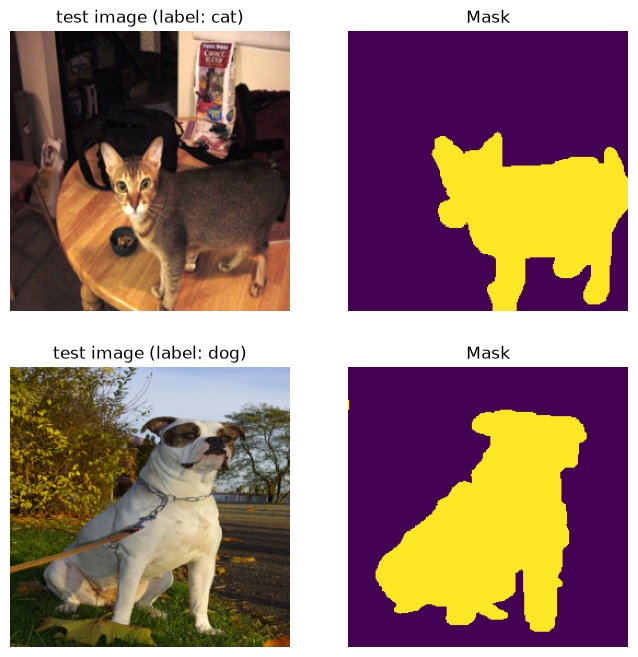

In [8]:
# lets look at a cat and a dog from each split
splits = [
    ("train", train_dataset),
    ("valid", valid_dataset),
    ("test", test_dataset),
]

for split_name, dataset in splits:
    plt.figure(figsize=(8, 8))
    for row, species_id in enumerate([0, 1]):
        index = get_species_indices(dataset, species_id, 1)[0]
        sample = dataset[index]

        plt.subplot(2, 2, 2 * row + 1)
        # for visualization we have to transpose back to HWC
        plt.imshow(sample["image"].transpose(1, 2, 0))
        plt.title(f"{split_name} image (label: {species_names[species_id]})")
        plt.axis("off")

        plt.subplot(2, 2, 2 * row + 2)
        # for visualization we have to remove 3rd dimension of mask
        plt.imshow(sample["mask"].squeeze())
        plt.title("Mask")
        plt.axis("off")
    plt.show()

## Model

The classification head is added to any model in the library by passing `aux_params` to the model constructor (see [docs](https://smp.readthedocs.io/en/latest/insights.html#aux-classification-output)). The head is built on top of the last encoder feature map: `pooling -> dropout -> linear (-> activation, optional)`.

When `aux_params` is provided, the model returns a tuple `(mask_logits, class_logits)` instead of just `mask_logits`.

We use `classes=1` and no activation: for the binary cat vs dog task the head outputs a single logit per image, the same way the segmentation head outputs logits for the binary mask, and both losses are computed from logits.

In [9]:
# Some training hyperparameters
EPOCHS = 10
T_MAX = EPOCHS * len(train_dataloader)
OUT_CLASSES = 1  # one mask channel and one classification logit (binary tasks)

In [10]:
class PetSpeciesModel(pl.LightningModule):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            # add the auxiliary classification head on top of the encoder;
            # no activation - the head returns logits
            aux_params={"pooling": "avg", "dropout": 0.5, "classes": out_classes},
            **kwargs,
        )

        # preprocessing parameters for image
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

        # for image segmentation dice loss could be the best first choice
        self.segmentation_loss_fn = smp.losses.DiceLoss(
            smp.losses.BINARY_MODE, from_logits=True
        )
        # a common choice for binary classification
        self.classification_loss_fn = torch.nn.BCEWithLogitsLoss()
        # weight of the classification loss in the total loss, tune it for your
        # task: the best value depends on the relative importance of the heads
        self.classification_loss_weight = 1.0

        # initialize step metrics
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, image):
        # normalize image here
        image = (image - self.mean) / self.std
        mask_logits, label_logits = self.model(image)
        return mask_logits, label_logits

    def shared_step(self, batch, stage):
        image = batch["image"]
        mask = batch["mask"]
        label = batch["label"]

        # image and mask checks are explained in the binary segmentation example
        assert image.ndim == 4
        h, w = image.shape[2:]
        assert h % 32 == 0 and w % 32 == 0
        assert mask.ndim == 4
        assert mask.max() <= 1.0 and mask.min() >= 0

        # classification label shape should be (batch_size, 1), values 0 or 1
        assert label.ndim == 2
        assert label.max() <= 1.0 and label.min() >= 0

        mask_logits, label_logits = self.forward(image)

        # both heads return logits and both losses are computed from logits;
        # the total loss is a weighted sum
        segmentation_loss = self.segmentation_loss_fn(mask_logits, mask)
        classification_loss = self.classification_loss_fn(label_logits, label)
        loss = segmentation_loss + self.classification_loss_weight * classification_loss

        # compute segmentation true positive, false positive, false negative and
        # true negative "pixels" for IoU (see the binary segmentation example)
        prob_mask = mask_logits.sigmoid()
        pred_mask = (prob_mask > 0.5).float()
        seg_tp, seg_fp, seg_fn, seg_tn = smp.metrics.get_stats(
            pred_mask.long(), mask.long(), mode="binary"
        )

        # ... and the same stats for the classification head, here `get_stats`
        # gets per-image predictions of shape (batch_size, 1) instead of masks
        prob_label = label_logits.sigmoid()
        pred_label = (prob_label > 0.5).float()
        cls_tp, cls_fp, cls_fn, cls_tn = smp.metrics.get_stats(
            pred_label.long(), label.long(), mode="binary"
        )

        return {
            "loss": loss,
            "segmentation_loss": segmentation_loss.detach(),
            "classification_loss": classification_loss.detach(),
            "seg_tp": seg_tp,
            "seg_fp": seg_fp,
            "seg_fn": seg_fn,
            "seg_tn": seg_tn,
            "cls_tp": cls_tp,
            "cls_fp": cls_fp,
            "cls_fn": cls_fn,
            "cls_tn": cls_tn,
        }

    def shared_epoch_end(self, outputs, stage):
        # aggregate step metrics
        seg_tp = torch.cat([x["seg_tp"] for x in outputs])
        seg_fp = torch.cat([x["seg_fp"] for x in outputs])
        seg_fn = torch.cat([x["seg_fn"] for x in outputs])
        seg_tn = torch.cat([x["seg_tn"] for x in outputs])
        cls_tp = torch.cat([x["cls_tp"] for x in outputs])
        cls_fp = torch.cat([x["cls_fp"] for x in outputs])
        cls_fn = torch.cat([x["cls_fn"] for x in outputs])
        cls_tn = torch.cat([x["cls_tn"] for x in outputs])

        # dataset-wise IoU for the segmentation head (aggregate intersection and
        # union over the whole dataset, then compute the score); see the binary
        # segmentation example for dataset-wise vs per-image IoU discussion
        dataset_iou = smp.metrics.iou_score(
            seg_tp, seg_fp, seg_fn, seg_tn, reduction="micro"
        )

        # accuracy and F1 for the classification head; any other classification
        # metric from `smp.metrics` can be computed from the same stats
        accuracy = smp.metrics.accuracy(
            cls_tp, cls_fp, cls_fn, cls_tn, reduction="micro"
        )
        f1_score = smp.metrics.f1_score(
            cls_tp, cls_fp, cls_fn, cls_tn, reduction="micro"
        )

        # mean losses over the epoch to see how each head is doing
        segmentation_loss = torch.stack(
            [x["segmentation_loss"] for x in outputs]
        ).mean()
        classification_loss = torch.stack(
            [x["classification_loss"] for x in outputs]
        ).mean()

        metrics = {
            f"{stage}_dataset_iou": dataset_iou,
            f"{stage}_accuracy": accuracy,
            f"{stage}_f1_score": f1_score,
            f"{stage}_segmentation_loss": segmentation_loss,
            f"{stage}_classification_loss": classification_loss,
        }
        self.log_dict(metrics, prog_bar=True)

    def training_step(self, batch, batch_idx):
        train_loss_info = self.shared_step(batch, "train")
        # append the metrics of each step to the outputs list
        self.training_step_outputs.append(train_loss_info)
        return train_loss_info

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        # empty set output list
        self.training_step_outputs.clear()

    def validation_step(self, batch, batch_idx):
        valid_loss_info = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(valid_loss_info)
        return valid_loss_info

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()

    def test_step(self, batch, batch_idx):
        test_loss_info = self.shared_step(batch, "test")
        self.test_step_outputs.append(test_loss_info)
        return test_loss_info

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        # empty set output list
        self.test_step_outputs.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }

In [11]:
model = PetSpeciesModel("FPN", "resnet34", in_channels=3, out_classes=OUT_CLASSES)

## Training

In [12]:
trainer = pl.Trainer(max_epochs=EPOCHS, log_every_n_steps=1)

trainer.fit(
    model,
    train_dataloaders=train_dataloader,
    val_dataloaders=valid_dataloader,
)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


C:\smp-run\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


## Validation and test metrics

In [13]:
# run validation dataset
valid_metrics = trainer.validate(model, dataloaders=valid_dataloader, verbose=False)
print(valid_metrics)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

[{'valid_dataset_iou': 0.9015180468559265, 'valid_accuracy': 0.9972826242446899, 'valid_f1_score': 0.9979959726333618, 'valid_segmentation_loss': 0.05277493596076965, 'valid_classification_loss': 0.003684787079691887}]


In [14]:
# run test dataset
test_metrics = trainer.test(model, dataloaders=test_dataloader, verbose=False)
print(test_metrics)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


C:\smp-run\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

[{'test_dataset_iou': 0.9053030014038086, 'test_accuracy': 0.9931861758232117, 'test_f1_score': 0.9949869513511658, 'test_segmentation_loss': 0.05130484327673912, 'test_classification_loss': 0.02184285782277584}]


## Result visualization

For each image we show the ground truth and predicted mask (segmentation head) together with the ground truth and predicted species with its probability (classification head). Both classes are included: the splits are ordered by breed, so a single batch of the test set would contain cats only.

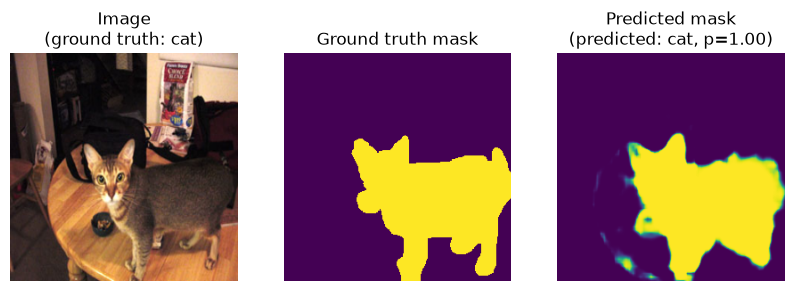

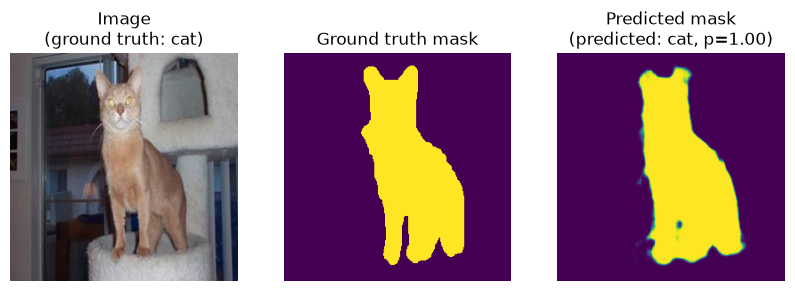

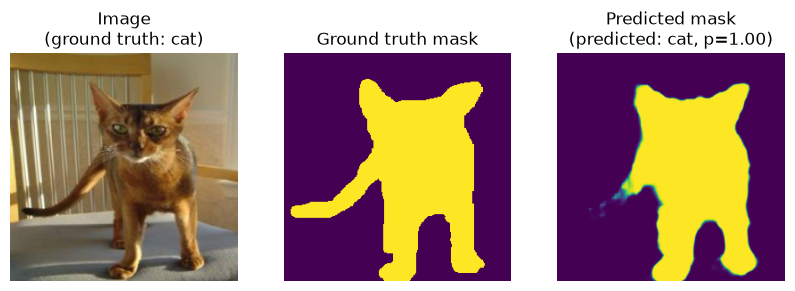

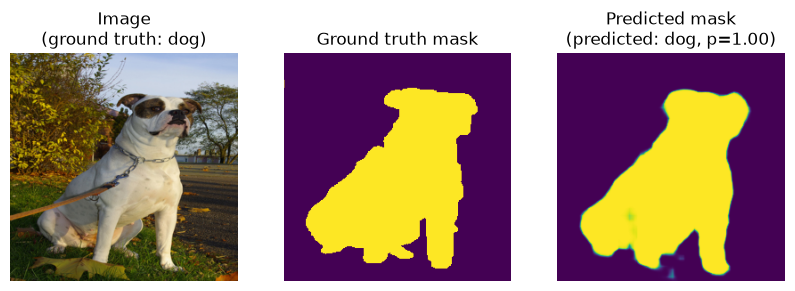

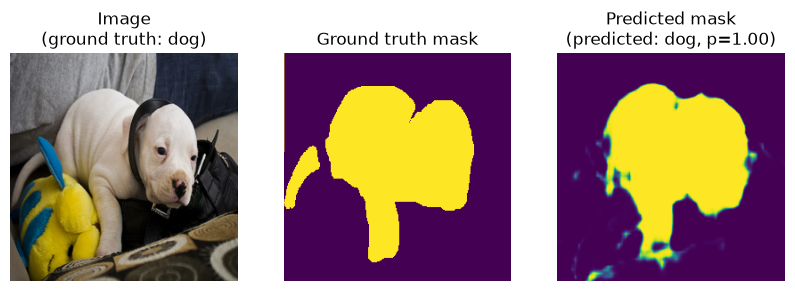

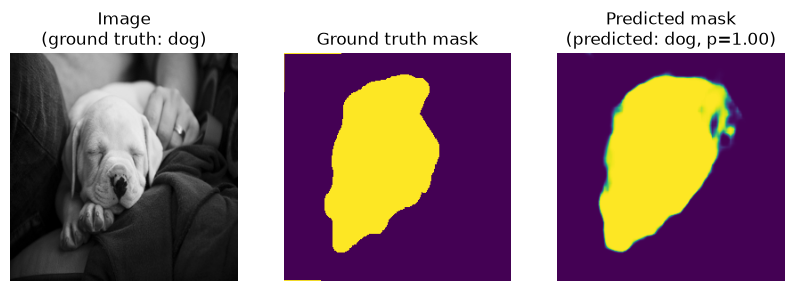

In [15]:
# take a few test samples of each species so that both classes are shown
indices = get_species_indices(test_dataset, 0, 3) + get_species_indices(
    test_dataset, 1, 3
)
batch = default_collate([test_dataset[index] for index in indices])

with torch.inference_mode():
    model.eval()
    mask_logits, label_logits = model(batch["image"])
pred_masks = mask_logits.sigmoid()
pred_species_probs = label_logits.sigmoid()

for idx, (image, gt_mask, pred_mask) in enumerate(
    zip(batch["image"], batch["mask"], pred_masks)
):
    gt_species = species_names[int(batch["label"][idx])]
    # the head returns a single logit: probability of the class `1` (dog)
    dog_prob = pred_species_probs[idx].item()
    pred_species = species_names[int(dog_prob > 0.5)]
    confidence = dog_prob if dog_prob > 0.5 else 1 - dog_prob

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image.numpy().transpose(1, 2, 0))
    plt.title(f"Image\n(ground truth: {gt_species})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask.numpy().squeeze())
    plt.title("Ground truth mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.numpy().squeeze())
    plt.title(f"Predicted mask\n(predicted: {pred_species}, p={confidence:.2f})")
    plt.axis("off")
    plt.show()